In [ ]:
from torch import nn
from torch.nn import functional as F
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm import tqdm

Matplotlib is building the font cache; this may take a moment.


# Convolutional AutoEncoder

## Model architecture and settings


In [ ]:
class Encoder(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.fc = nn.Linear(64*7*7, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.flatten(start_dim=1)
        x = self.fc(x)
        return x
    
class Decoder(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.fc = nn.Linear(10, 64*7*7)
        self.conv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        batch_size = x.shape[0]
        x = F.relu(self.fc(x))
        x = x.reshape((batch_size,64,7,7))
        x = F.relu(self.conv1(x))
        x = F.sigmoid(self.conv2(x))
        return x
    
class ConvolutionalAutoEncoder(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

## Experiments

In [32]:
import torch
from torchvision import datasets, transforms

# Transform to convert images to tensors
transform = transforms.Compose([transforms.ToTensor()])

# Download and load training/testing datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Optional: Wrap in a DataLoader
train_loader = torch.utils.data.DataLoader(train_dataset.data.unsqueeze(1), batch_size=128, shuffle=True)

In [58]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("using: ", device)
conv_autoencoder = ConvolutionalAutoEncoder().to(device=device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    params=conv_autoencoder.parameters(),
    lr=1e-3 
)

conv_autoencoder.train()

for _ in range(10):
    pbar = tqdm(enumerate(train_loader))
    for batch_idx, data in pbar:
        data = data.to(device).to(torch.float)

        optimizer.zero_grad()
        out_img = conv_autoencoder(data)
        loss = criterion(out_img, data)
        loss.backward()
        optimizer.step()

        pbar.set_description(f"Loss: {loss.item()}")


using:  cuda


Loss: 7419.20654296875: : 469it [00:02, 200.52it/s]
Loss: 6920.1171875: : 469it [00:02, 198.04it/s]    
Loss: 7244.40478515625: : 469it [00:02, 206.82it/s]
Loss: 7500.314453125: : 469it [00:02, 208.22it/s]  
Loss: 7057.27294921875: : 469it [00:02, 220.53it/s]
Loss: 7312.1630859375: : 469it [00:02, 224.55it/s] 
Loss: 6786.1435546875: : 469it [00:02, 224.04it/s] 
Loss: 7359.65283203125: : 469it [00:01, 238.90it/s]
Loss: 7044.7822265625: : 469it [00:01, 235.92it/s] 
Loss: 7182.85693359375: : 469it [00:02, 229.59it/s]


torch.Size([1, 1, 28, 28])


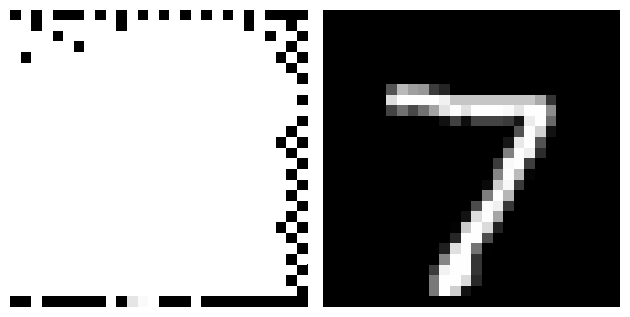

In [ ]:
conv_autoencoder.eval()

with torch.no_grad():
    test_example = test_dataset.data[0].unsqueeze(0).unsqueeze(0).to(device).to(torch.float)
    reconstruct_example = conv_autoencoder(test_example)

fig, (ax1, ax2) = plt.subplots(1,2)

ax1.imshow(reconstruct_example.squeeze(0).permute(1, 2, 0).cpu(), cmap='gray')
ax1.axis("off")

ax2.imshow(test_example.squeeze(0).permute(1,2,0).cpu(),cmap='gray')
ax2.axis('off')
plt.tight_layout()
plt.show()

## MSE vs BCE

In [ ]:
del conv_autoencoder
del criterion 
del optimizer

In [80]:
conv_autoencoder = ConvolutionalAutoEncoder().to(device=device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(
    params=conv_autoencoder.parameters(),
    lr=1e-3 
)

conv_autoencoder.train()

for _ in range(10):
    pbar = tqdm(enumerate(train_loader))
    for batch_idx, data in pbar:
        data = data.to(device).to(torch.float)

        optimizer.zero_grad()
        out_img = conv_autoencoder(data)
        loss = criterion(out_img, data)
        loss.backward()
        optimizer.step()

        pbar.set_description(f"Loss: {loss.item()}")

0it [00:00, ?it/s]


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
